In [8]:
# %% Imports
from jax import random, numpy as jnp

from modax.data.kdv import DoubleSoliton
from modax.models import DeepmodBayes
from flax import optim
from modax.losses import loss_fn_pinn_stateful

from conditional_gaussian import *

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
# %% Making data
key = random.PRNGKey(42)

x = jnp.linspace(-10, 10, 100)
t = jnp.linspace(0.1, 1.0, 10)
t_grid, x_grid = jnp.meshgrid(t, x, indexing="ij")

u = DoubleSoliton(x_grid, t_grid, c=[5.0, 2.0], x0=[0.0, -5.0])

X = jnp.concatenate([t_grid.reshape(-1, 1), x_grid.reshape(-1, 1)], axis=1)
y = u.reshape(-1, 1)
y += 0.1 * jnp.std(y) * random.normal(key, y.shape)

y_normed = y / jnp.std(y)

In [14]:
from modax.data.burgers import burgers

x = jnp.linspace(-3, 4, 50)
t = jnp.linspace(0.5, 5.0, 20)
t_grid, x_grid = jnp.meshgrid(t, x, indexing="ij")
u = burgers(x_grid, t_grid, 0.1, 1.0)

X = jnp.concatenate([t_grid.reshape(-1, 1), x_grid.reshape(-1, 1)], axis=1)
y = u.reshape(-1, 1)
y += 0.10 * jnp.std(y) * random.normal(key, y.shape)
y_normed = y / jnp.std(y)


In [40]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [41]:
optimizer, state = train(
    model,
    optimizer,
    state,
    loss_fn_scaled,
    X,
    y_normed,
    max_epochs=1e4,
    split=0.8,
    rand_seed=42,
)

Loss step 0.0: 2445.369140625
Loss step 1000.0: -5471.58544921875
Loss step 2000.0: -5489.283203125
Loss step 3000.0: -5291.095703125
Loss step 4000.0: -7454.83349609375
Loss step 5000.0: -7086.5244140625
Loss step 6000.0: -3213.302734375
Loss step 7000.0: -5994.94921875
Loss step 8000.0: -6409.27880859375
Loss step 9000.0: -6680.04296875


In [42]:
variables = {"params": optimizer.target, **state}
prediction, dt, theta, coeffs, _ = model.apply(variables, X, mutable=list(state.keys()))[0]

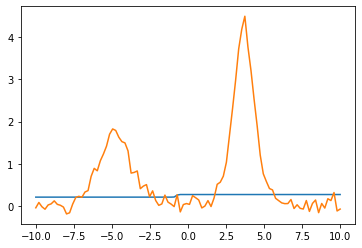

In [43]:
frame = 5
plt.plot(x, prediction.reshape(x_grid.shape)[frame, :])
plt.plot(x, y_normed.reshape(x_grid.shape)[frame, :])

In [35]:
rho = jnp.corrcoef(jnp.concatenate([prediction, dt], axis=1).T)[0, 1]
print(rho)

0.023841778


In [36]:
sigma_mse = jnp.sqrt(jnp.mean((prediction - y_normed) ** 2))
p_mse, MSE = normal_LL(prediction, y_normed, 1 / sigma_mse ** 2)
print(MSE, p_mse, sigma_mse)

0.006526815 1096.9797 0.0807887


AttributeError: '_DeviceArray' object has no attribute 'val'

In [37]:
dt_normed = dt #/ jnp.std(dt)
theta_normed = theta# / jnp.std(dt)

sigma_reg = jnp.sqrt(jnp.mean((dt_normed - theta_normed @ coeffs) ** 2))
print(sigma_reg)

8.1331393e-07


In [127]:
jnp.mean(((dt - theta @ coeffs)) ** 2)

DeviceArray(1.7433521e-06, dtype=float32)

In [77]:
jnp.linalg.norm(dt)

DeviceArray(2.3021212, dtype=float32)

In [78]:
jnp.std(dt)

DeviceArray(0.06497981, dtype=float32)

In [57]:
jnp.sqrt(jnp.mean((prediction - y ) ** 2))

DeviceArray(0.68462956, dtype=float32)

In [58]:
jnp.linalg.norm(prediction)

DeviceArray(1.5938553, dtype=float32)

In [60]:
jnp.std(prediction)

DeviceArray(0.04725558, dtype=float32)

In [86]:
coeffs

DeviceArray([[ 3.1355646e-02],
             [-1.4861667e-01],
             [ 6.0290762e-04],
             [ 4.7548171e-04],
             [ 4.8266584e-03],
             [-4.8141706e-01],
             [-3.2035249e-01],
             [ 1.6725417e-02],
             [-1.7939992e-01],
             [-3.4055095e-02],
             [ 1.0355452e-01],
             [-1.1502206e+00]], dtype=float32)

In [88]:
coeffs[:, None] / jnp.linalg.norm(theta, axis=0)[:, None]

DeviceArray([[[ 9.9155260e-04],
              [ 3.4373503e-02],
              [ 6.6513913e-03],
              [ 1.2720085e-03],
              [ 3.8231883e-02],
              [ 1.2613654e+00],
              [ 2.3478901e-01],
              [ 4.4428471e-02],
              [ 9.1239154e-01],
              [ 3.3832737e+01],
              [ 5.7618561e+00],
              [ 1.0859460e+00]],

             [[-4.6996721e-03],
              [-1.6292045e-01],
              [-3.1525668e-02],
              [-6.0289516e-03],
              [-1.8120804e-01],
              [-5.9785061e+00],
              [-1.1128318e+00],
              [-2.1057808e-01],
              [-4.3244715e+00],
              [-1.6035738e+02],
              [-2.7309528e+01],
              [-5.1470690e+00]],

             [[ 1.9065614e-05],
              [ 6.6093513e-04],
              [ 1.2789322e-04],
              [ 2.4458232e-05],
              [ 7.3512422e-04],
              [ 2.4253584e-02],
              [ 4.5145326e-03],
    